# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/solasobambo-prog/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question
**Decision:** Which visible pages, pages getting real search impressions, should a content editor review first because they're under capturing clicks relative to their position?

**Who acts, and how:** A content editor or SEO reviewer opens the flagged pages and decides whether to rewrite the title, meta description, or snippet, whether to escalate to engineering if tracking looks broken, or whether to schedule a content refresh.

**Why not a simple threshold:** Expected CTR varies roughly 6.4x by position tier (0.355 at page_1 down to 0.055 at deep), so a single fixed cutoff like "flag anything under 1%" would misclassify most pages. A page has to be compared only to others in its own position tier, with enough impressions to trust the comparison.

**Cost of a wrong call:** a false positive costs an editor's review time on a page that didn't need it. A false negative lets a real under capturing page keep losing clicks unnoticed.

**One paragraph frame:** for a content editor deciding which pages to review first, this project builds a ranked queue from FlyRank's starter search dataset, scoring pages by how far their CTR falls below their position tier's expected CTR, adjusted for volume, and separated by likely cause (a genuine CTR gap, a tracking anomaly, or page one content grown stale). The result claims only observed, directional, decision support patterns, never proof that a specific fix will work, and never a claim about how Google's algorithm itself behaves.



## 2. Data

**Release:** the FlyRank ML Internship starter dataset, `data/raw/content_refresh_anonymized.csv`, one row per content item (page), 30,000 rows across 44 columns, covering 32 pseudonymized clients. This is the sanctioned dataset for the CTR/Engagement Opportunity Scoring lane, the larger ~79 million row warehouse release was available but not required, and the starter slice already gave enough volume (22,006 to 30,000 pages depending on the trust floor applied) to build and validate a ranked queue.

**Date window:** all metrics are aggregated over a trailing 90-day window ending at the slice's export snapshot. No absolute calendar date is published for this slice specifically, unlike the full warehouse release, which is a fixed export dated 2026-07-03, this starter slice is a relative trailing window, not a dated point in time.

**What was excluded, and why:**

- **No client names, domains, URLs, raw queries, or credentials anywhere in the data.** `content_id` and `client_id` are pseudonymous identifiers (`content_` + 12 hex characters, `client_` + 10 hex characters), used only for grouping and joins, never as model features or shown in any output.

- **Rows below the trust floor were excluded from ranking, not deleted from analysis.** Pages with fewer than 500 impressions over the 90 day window don't have a reliable enough CTR to compare against a tier average, so they're visible in the underlying data but never enter the ranked queue.
- **`trend_direction` and `trend_pct` were excluded as features everywhere in this project,** per this dataset's own documented leakage warning, since the label is derived directly from trend_direction, using it as an input would be circular.

- **The full ~79 million row warehouse release was not used.** It's available and gated behind a free Hugging Face request, but the starter slice already supports this lane by design, using it kept the project's scope and runtime manageable across an 8 week track without sacrificing a valid result.

## 3. Methodology

**Label definition:** `ctr_gap = ctr - tier_avg_ctr`, where `tier_avg_ctr` is the mean CTR within each `position_tier`, computed only on pages with `impressions_90d >= 100` (the trust floor). This is a proxy label, not an outcome FlyRank measured, there is no ground truth "this page underperforms" flag in the data.

**Baseline (ML-07):** a rule, not a model. Flags a page when its CTR sits below its own tier's average, with volume as a secondary weight. By construction its R² on `ctr_gap` is 0, it uses only the columns the gap is built from, so it never "predicts" anything, it measures the gap directly.

**Assumptions:** a page's expected CTR depends on its position tier, not a single global average, confirmed by the roughly 6.4x spread between tiers. Pages need at least 100 impressions in the 90 day window to trust their CTR at all. All model features had to be knowable independent of the label's own ingredients.

**Features tested (Week 5):** `content_type`, `main_intent`, `freshness_tier`, `age_tier`, `search_volume`, `competition`, `cpc`, `word_count`, all confirmed independent of the label. Deliberately excluded: ctr, `position_tier`, `tier_avg_ctr`, `avg_position` (the label's direct ingredients), and `impressions_90d` (used only to define the trustworthy population, never as a feature).

**Validation design:** `GroupShuffleSplit` on `client_id`, 80/20, confirmed 0 shared clients between train and test. Pages from the same client share editorial and keyword patterns, a random row split would let the model see a client's quirks in both train and test and get credit for memorizing rather than generalizing.

**Leakage checks, three separate ones across the project:**

- **Week 3, an early sanity demonstration on real warehouse data:** deliberately added `ctr` as a feature predicting `ctr_gap`. Honest model (position + impressions only): R² = 0.002. Leaky model (with `ctr` added): R² = 1.000, a perfect, meaningless score, since `ctr_gap` is algebraically just `ctr` minus a constant.
- **Week 6, naive vs. grouped split, same features and models as Week 5:** a naive random row split gave misleadingly positive scores (Linear R² = 0.0431, Random Forest R² = 0.0917), with 28 of 30 clients appearing in both train and test. The honest, client grouped split (Week 5's actual design) revealed the real result: negative for both (Linear −0.5398, Random Forest −1.5655). Reporting the naive number would have looked like a working model; it was a leakage driven illusion.
- **Week 6, harness verification:** deliberately reintroduced `ctr` into the honest, grouped-split pipeline. R² jumped from −1.5655 to 0.9204, confirming the test harness correctly rewards a real leak when one exists, so the negative results elsewhere were a genuine finding, not a broken pipeline silently returning garbage.

**Root cause of the Random Forest's failure, found by ablation (Week 5):** one training-only client, `client_d4735e3a26` (61 rows), had a mean `ctr_gap` of 2.593, wildly outside every other client's range (next highest 0.841). Retraining without that client moved R² from −1.5655 to −0.0702, nearly matching the trivial `DummyRegressor` baseline of −0.0143. One noisy client, not a real content signal, was driving most of the model's damage; permutation importance corroborated this, every feature scored zero or negative importance, with `content_type` and `age_tier` (the categorical splits that client would pull hardest on) most negative.

**Conclusion carried into the rest of this project:** content and keyword metadata do not meaningfully explain the CTR gap in this dataset. The Week 4 rule was kept as the production method, not as a fallback, it was validated as the better choice. From ML-10 onward, that rule was refined into three archetypes (a genuine CTR gap, a likely tracking anomaly, and stale page-one content), each independently validated against the underlying data (population-preserving checks, a staleness fix that dropped a flawed archetype from 2,047 to 13 rows, a volume-dampened ranking that changed 7 of the old top 10).


## 4. Results (vs baseline)

**Comparison 1: model vs. baseline, on the same client-grouped test split, predicting
`ctr_gap`:**

| Model | R² (test) | MAE (test) |
|---|---|---|
| Baseline rule (ML-07) | 0.0000 | n/a |
| DummyRegressor (train mean) | −0.0143 | 0.2192 |
| Linear Regression | −0.5398 | 0.2713 |
| Random Forest (depth=6) | −1.5655 | 0.3087 |

Neither model beat the baseline, or even a trivial mean predictor. The rule stays the
shipped method, not a fallback.

**Comparison 2: naive rule vs. refined rule, on the full 30,000-row starter dataset:**

| | Naive rule (ML-07, single score) | Refined rule (ML-10, three archetypes) |
|---|---|---|
| Total flagged | 11,016 (36.7%) | 11,029 (36.8%, CTR-gap population unchanged) |
| Ranking method | `impressions_90d × abs(ctr_gap)` | `abs(ctr_gap) × log1p(impressions_90d)` |
| Top 10 overlap after the fix | — | only 3 of 10 rows unchanged |
| Worst known failure mode | a 517,109-impression page with only a 0.10 gap ranked #1 | that exact page is confirmed absent from the new top 10 |

The refined rule doesn't flag a different population, the same 11,000-ish pages are
still the ones worth reviewing, but it ranks them in a materially different order: 7 of
the old top 10 were volume-driven artifacts, not genuine large gaps.

**Figures:** `work/figures/reason_code_distribution.png` (the four archetypes and their
counts) and `work/figures/rank_score_before_after.png` (which pages moved in/out of the
top 10, and why).

## 5. Limitations

**Who this is for and where it stops applying:** decision support for content editors, SEO reviewers, engineering (for tracking anomalies), and content strategy, never for automated publishing, writer grading, or a client-facing recovery promise.

- **Sample, not full population.** 30,000 rows, 32 pseudonymized clients, a trailing 90-day snapshot. Findings describe this sample, not FlyRank's full ~79 million row inventory.
- **A validated choice, not a fallback.** The rule based baseline was kept because it beat two tested model alternatives on an honest, client-grouped split, not because modeling wasn't attempted.
- **`ctr_gap` is a constructed proxy, not an observed outcome.** FlyRank doesn't record "this page underperformed"; tier averages are computed from this sample alone and will shift if search behavior changes.
- **Model features had real missingness** (`main_intent` 7.9%, `search_volume`/`competition`/`cpc` 8.2%, `word_count` 25.7%), imputed rather than dropped, a source of noise in an already negative result.
- **The CTR-gap archetype under-covers `top_3` and `deep` tiers** (2.2% and 0.6% of the archetype combined), while striking, `page_3_5`, and `page_1` are each roughly a third, an artifact of how tier average CTR concentrates the visible gap.
- **The decay-risk archetype is small and confounded.** At n=15 after requiring staleness on two measures, it's too small to treat as a stable pattern, and all 15 rows share the same content type and position tier, which this data can't separate from a genuine concentration effect.
- **Page grain, not query grain.** A flag points at a page, not which specific queries drive the shortfall; a human still needs Search Console before deciding what to change.
- **No causal claim, and no claim about how Google's ranking algorithm works.** Every archetype says where to look, not what's wrong, whether a fix will work, or anything about the mechanics of search ranking itself. This project makes no attempt to reverse-engineer or model Google's algorithm, and no recommended action is claimed to cause a measurable outcome.

## 6. Ranked recommendations

This section summarizes the full Content Action Playbook built in
`w07_action_playbook.ipynb` (ML-10). Full detail, code, and validation live there; this
is the ranked-recommendation summary the paper reports.

**Three archetypes, each routed to a different owner:**

| Archetype | Rule | Reason code | Action | Owner |
|---|---|---|---|---|
| CTR gap, real | visible, `ctr > 0`, below tier average | `ctr_below_tier_visible` | Review title, meta, snippet | Content editor / SEO |
| Tracking gap suspect | visible, `ctr == 0` | `possible_tracking_gap` | Verify tracking setup | Engineering / analytics |
| Page-one decay risk | page-one, old by two staleness measures, low n (15) | `page_one_decay_risk` | Schedule content refresh | Content strategy |

**Ranking:** within the CTR-gap archetype, pages are ranked by gap size dampened by
audience size (`abs(ctr_gap) × log1p(impressions_90d)`), not raw volume times gap,
which changed 7 of the old top 10 (Section 4).

**What should never be automated:** auto-editing or auto-publishing titles, meta,
snippets, or content; treating a flag as a performance review of a writer or editor; a
client-facing promise built on `estimated_impact` (a sizing estimate, not a tested
recovery number); reintroducing the failed Week 5 model as a confidence weight; routing
tracking-gap rows to content editors by default; collapsing the three reason codes into
one blended score.

**Human review before acting:** confirm `impressions_90d` still clears the archetype's
floor against current data; confirm a zero-CTR flag in the actual analytics account
before looping in content; check `days_since_last_update` before queuing a refresh a
page may have already received; review the 15 decay-risk rows individually given the
small sample.

**Monitoring/retrain triggers:** a shift in the reason-code mix (especially a rising
tracking-gap share), tier-average CTR drift, a content-type mix shift given how
concentrated `keyword article` already is, and a materially larger, more diverse dataset
as the only condition worth revisiting the abandoned model approach.

## 7. Artifacts the paper embeds

Two figures already exist from ML-10 (`reason_code_distribution.png`, `rank_score_before_after.png`). One new figure is built here, the model vs. baseline comparison, since Results currently only has that as a table. The code cell below also prints a full inventory of every artifact the paper embeds, with a one-line caption for each, so the deployment step has a checklist rather than a memory exercise.

In [3]:
import os, subprocess

if not os.path.exists("data/raw/content_refresh_anonymized.csv"):
    if not os.path.isdir("flyrank-ml-internship"):
        subprocess.run(
            ["git", "clone", "--depth", "1",
             "https://github.com/solasobambo-prog/flyrank-ml-internship.git"],
            check=True,
        )
    os.chdir("flyrank-ml-internship")

print("Working directory:", os.getcwd())
print("Figures already present:", os.listdir("work/figures") if os.path.exists("work/figures") else "work/figures not found")

Working directory: /content/flyrank-ml-internship
Figures already present: ['model_vs_baseline_r2.png', 'rank_score_before_after.png', 'reason_code_distribution.png']


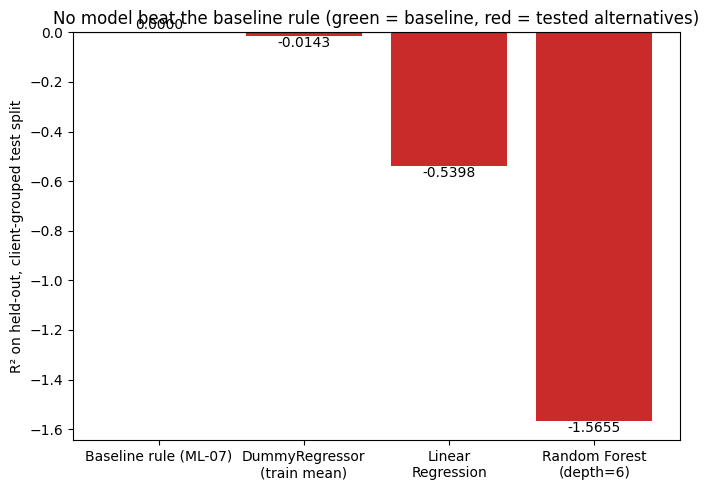

Artifacts this paper embeds:
✅  work/figures/model_vs_baseline_r2.png
    -> Results: no model beat the baseline rule
✅  work/figures/reason_code_distribution.png
    -> Ranked recommendations: rows by archetype
✅  work/figures/rank_score_before_after.png
    -> Results: volume-dampened ranking changed 7 of the old top 10
✅  work/outputs/playbook_monitoring_baseline.json
    -> Reproducibility: the metrics receipt future runs check against
❌ MISSING  work/outputs/content_action_playbook_queue.csv
    -> Not embedded (gitignored by design); regenerated by w07, not shipped in the paper


In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import os

# The model-vs-baseline table from Section 4, rendered as a chart for the first time
results = pd.DataFrame([
    {"model": "Baseline rule (ML-07)", "r2": 0.0000},
    {"model": "DummyRegressor\n(train mean)", "r2": -0.0143},
    {"model": "Linear\nRegression", "r2": -0.5398},
    {"model": "Random Forest\n(depth=6)", "r2": -1.5655},
])

fig, ax = plt.subplots(figsize=(7, 5))
colors = ["#2b8a3e" if v == 0 else "#c92a2a" for v in results["r2"]]
bars = ax.bar(results["model"], results["r2"], color=colors)
ax.bar_label(bars, fmt="%.4f")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("R² on held-out, client-grouped test split")
ax.set_title("No model beat the baseline rule (green = baseline, red = tested alternatives)")
plt.tight_layout()

os.makedirs("work/figures", exist_ok=True)
plt.savefig("work/figures/model_vs_baseline_r2.png", dpi=150)
plt.show()

# Full inventory of everything the deployed paper embeds
artifacts = [
    ("work/figures/model_vs_baseline_r2.png", "Results: no model beat the baseline rule"),
    ("work/figures/reason_code_distribution.png", "Ranked recommendations: rows by archetype"),
    ("work/figures/rank_score_before_after.png", "Results: volume-dampened ranking changed 7 of the old top 10"),
    ("work/outputs/playbook_monitoring_baseline.json", "Reproducibility: the metrics receipt future runs check against"),
    ("work/outputs/content_action_playbook_queue.csv", "Not embedded (gitignored by design); regenerated by w07, not shipped in the paper"),
]

print("Artifacts this paper embeds:")
for path, caption in artifacts:
    exists = "✅" if os.path.exists(path) else "❌ MISSING"
    print(f"{exists}  {path}\n    -> {caption}")

## 8. 5-minute demo outline


1. **Question (30s):** "A page can rank on page one of Google and still barely get clicked. Across FlyRank's client base, which of those pages should a content editor look at first?"

2. **Method (60s):** Compare each page's click-through rate only to other pages at the same search position, since a page one result and a page three result don't have the same click ceiling. Split flagged pages into three types, a genuine CTR gap, a likely tracking issue, and stale page-one content, each going to a different person to check.

3. **One chart (90s):** Show `model_vs_baseline_r2.png`. "I tried to replace this rule with a machine learning model. It lost, badly, worse than just guessing the average. Here's why that's actually a good outcome to report."

4. **One honest result (60s):** The model's failure traced to one outlier client dominating training, removing that client brought the score back near trivial, confirming the model memorized noise, not a pattern. The simpler rule stayed the shipped method because it earned that spot, not by default.

5. **One recommendation (60s):** Switching the ranking from raw volume-times-gap to a volume-dampened score changed 7 of the old top 10 recommended pages, including removing a 517,000-impression page that only had a middling gap and had been ranking #1 for the wrong reason. That's the concrete, shippable output: a ranked queue an editor can act on today.

**Close:** "Full paper and reproducible notebooks at https://solasobambo-prog.github.io/flyrank-ml-internship/."

##9. Two shareable cuts

**Social post (methodology-focused):**

Most people fix underperforming pages by gut feeling. I tried something more honest: build a rule, then genuinely try to beat it with ML, then report what actually happened.

Working with FlyRank's search performance data, I built a rule that flags pages under-capturing clicks relative to their own search position, not against a flat threshold, since a page one result and a page three result don't have the same click ceiling.

Then I tried to replace that rule with a Random Forest. It lost. Badly, worse than just predicting the average. I didn't hide that, I traced it to one outlier client dominating training and reported it as the finding it was: sometimes a transparent rule beats a model, and knowing why matters more than the model working.

The shipped result is a ranked queue split into three types of pages, a real CTR gap, a likely tracking issue, and stale content, each going to a different person to check. Full paper and reproducible notebooks linked below.

**Employer-facing summary (exactly 3 sentences):**

I built a rule-based system that ranks which underperforming pages a content team should review first, using FlyRank's anonymized search performance data across 32 clients.

It compares each page's click-through rate against others at the same search position, splits flagged pages into three actionable categories, and honestly reports that a tested machine learning alternative failed its own validation and was rejected in favor of the simpler, transparent method.

The result is a ranked, reason-coded queue that changed 7 of its own top 10 recommendations after a validation fix, evidence the system improved under scrutiny rather than just running once and shipping.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [x] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [x] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
